In [56]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Layer, Conv2D, GlobalAveragePooling2D, Input, Multiply, Dense, Flatten
from tensorflow.keras.models import Model
#from tensorflow.keras.layers.experimental.preprocessing import RandomRotation, RandomZoom, RandomTranslation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np


In [57]:
def delta_scale(image):
    relu = tf.keras.layers.ReLU()
    image = relu(image - 0.05)  # Apply ReLU to (image - 0.05)
    image = tf.minimum(255.0, 1000.0 * image)  # Scale by 1000 and cap at 255
    return image

def preprocess_image(image):
    image = tf.image.resize(image, [224, 224])
    return image

def preprocess_image_map_fn(image, label):
    return preprocess_image(image), label


In [58]:
def spatial_attention_module(x):
    # Define the spatial attention module
    avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
    concat = tf.concat([avg_pool, max_pool], axis=-1)
    attention = tf.keras.layers.Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return x * attention


In [59]:
class SpatialAttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionLayer, self).__init__(**kwargs)

    def call(self, inputs):
        return spatial_attention_module(inputs)

In [60]:
def build_resnet50_with_attention(input_shape):
    input_tensor = Input(shape=input_shape)
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)
    
    # Add attention module to a specific layer
    x = base_model.get_layer("conv4_block6_out").output
    x = SpatialAttentionLayer()(x)
    
    # Continue with the rest of the ResNet50 layers
    x = base_model.get_layer("conv5_block1_out").output
    x = GlobalAveragePooling2D()(x)
    x = Flatten()(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=input_tensor, outputs=output)
    return model

input_shape = (224, 224, 3)  # Even though the images are grayscale, we stack them to 3 channels
model = build_resnet50_with_attention(input_shape)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-6), loss='binary_crossentropy', metrics=['accuracy'])


In [61]:
def load_and_preprocess_data(data_dir, validation_split=0.30, batch_size=32):
    train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset='training',
        seed=123,
        image_size=(224, 224),
        batch_size=batch_size,
        label_mode='binary'
    ).map(preprocess_image_map_fn)

    validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        validation_split=validation_split,
        subset='validation',
        seed=123,
        image_size=(224, 224),
        batch_size=batch_size,
        label_mode='binary'
    ).map(preprocess_image_map_fn)
    
    # Prefetch to optimize performance
    train_dataset = train_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    validation_dataset = validation_dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

    return train_dataset, validation_dataset

data_dir = "dataset_SIDDHI"
train_dataset, validation_dataset = load_and_preprocess_data(data_dir)
print(f"{tf.data.Dataset.cardinality(train_dataset)} {tf.data.Dataset.cardinality(validation_dataset)}")


Found 9000 files belonging to 2 classes.
Using 6300 files for training.
Found 9000 files belonging to 2 classes.
Using 2700 files for validation.
Tensor("DatasetCardinality_12:0", shape=(), dtype=int64) Tensor("DatasetCardinality_13:0", shape=(), dtype=int64)


In [62]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 14,646,145 (55.87 MB)

 Trainable params: 14,605,313 (55.71 MB)

 Non-trainable params: 40,832 (159.50 KB)

In [63]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=40, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_resnet_attn.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

In [64]:
model.fit(train_dataset, validation_data=validation_dataset, epochs=200, batch_size=64, callbacks = [early_stopping, model_checkpoint, reduce_lr])


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'SymbolicTensor'

In [ ]:
new_model = tf.keras.models.load_model('90_resnet_attn.h5')
test_results = {}
test_results['Model'] = new_model.evaluate(train_dataset)
print(f"test_accuracy: {test_results}")

197/197 [==============================] - 48s 225ms/step - loss: 0.2843 - accuracy: 0.9111
test_accuracy: {'Model': [0.2843271791934967, 0.9110546112060547]}


In [ ]:
def load_and_preprocess_image(image_path):
    # Load the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image = preprocess_image(image)
    # Add a batch dimension
    image = tf.expand_dims(image, axis=0)
    return image

image_path = 'complete/normal/Normal10784.jpg'
image = load_and_preprocess_image(image_path)

# Make predictions
prediction = model.predict(image)
predicted_class = np.round(prediction).astype(int)

# Output the result
print(f'Predicted class: {predicted_class[0][0]}')


In [ ]:
def extract_images_and_labels(dataset):
    images = []
    labels = []
    for image_batch, label_batch in dataset.take(len(dataset)):
        images.extend(image_batch.numpy())
        labels.extend(label_batch.numpy())
    return np.array(images), np.array(labels)

val_images, val_labels = extract_images_and_labels(test_dataset)

1/1 [==============================] - ETA: 0s

C:\Users\aruna\AppData\Local\Temp\ipykernel_123616\4265830126.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f'True: {int(true_label)}, Pred: {pred_label}')


1/1 [==============================] - 0s 20ms/step


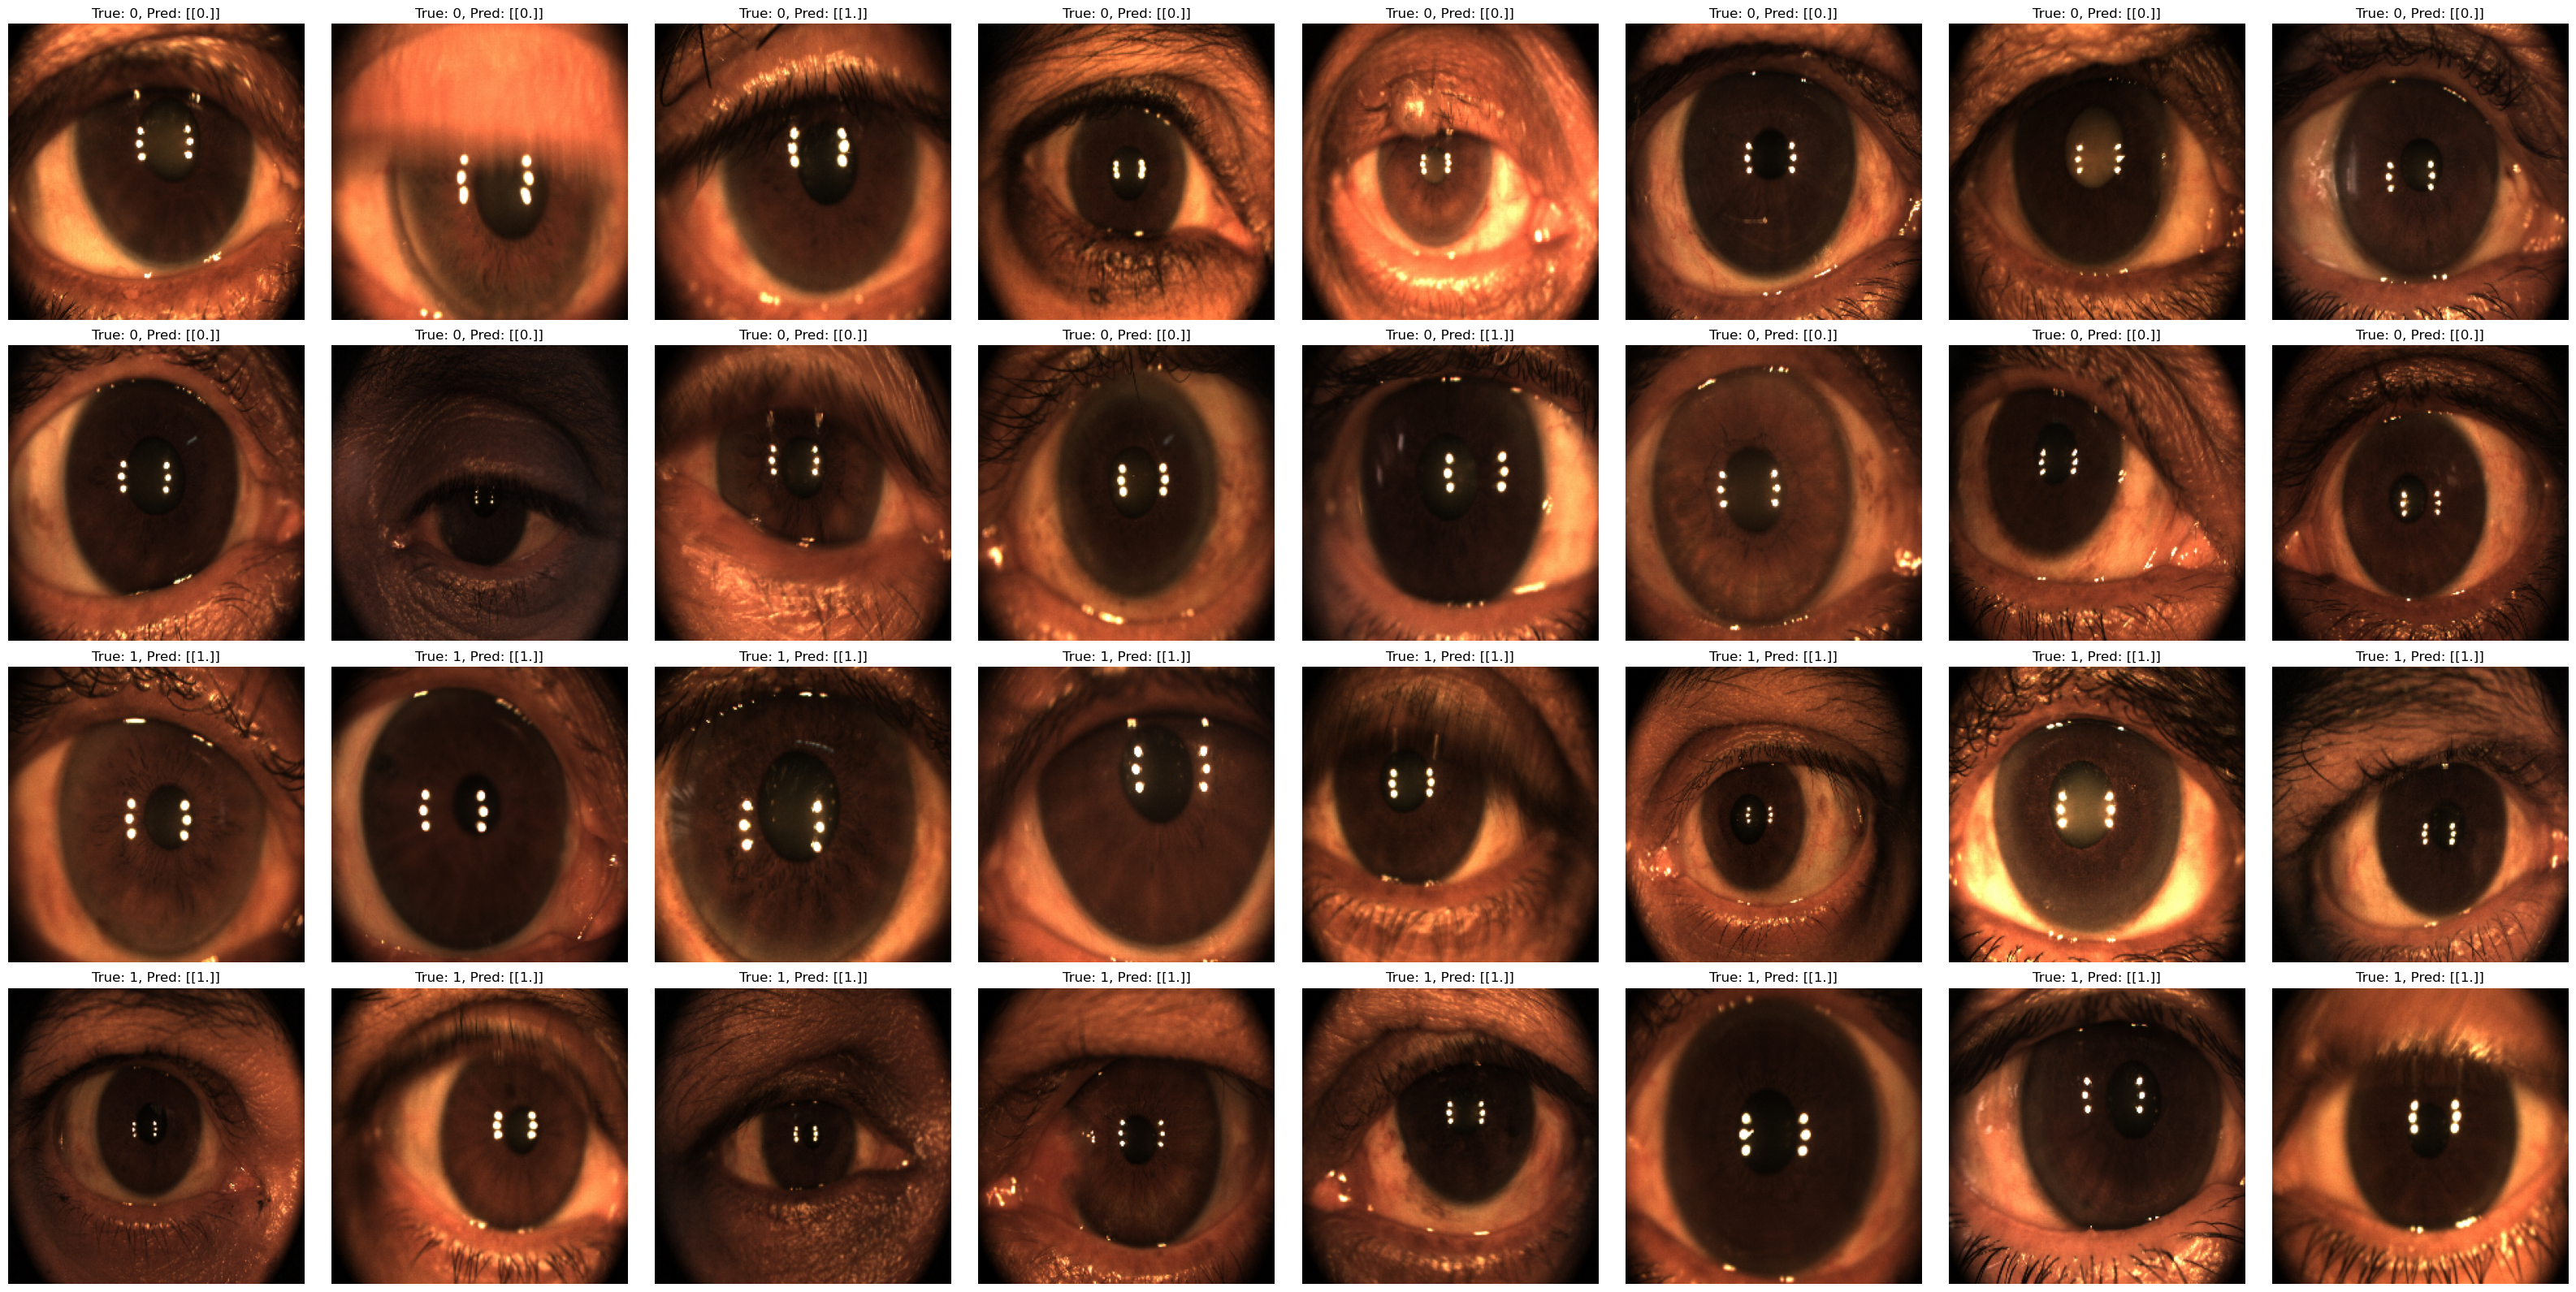

In [ ]:
import matplotlib.pyplot as plt
import random


def display_predictions(model, val_images, val_labels):
    plt.figure(figsize=(32, 16))
    indices = []
    for label in [0, 1]:
        label_indices = np.where(val_labels == label)[0]
        indices.extend(random.sample(list(label_indices), 8))
        indices.extend(random.sample(list(label_indices), 8))
    
    for i, idx in enumerate(indices):
        img = val_images[idx]
        true_label = val_labels[idx]
        pred_label = ((model.predict(np.expand_dims(img, axis=0)))).round(0)

        plt.subplot(4, 8, i+1)
        plt.imshow(img.squeeze() / 255)
        plt.title(f'True: {int(true_label)}, Pred: {pred_label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display predictions
display_predictions(new_model, val_images, val_labels)
